In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons
import os

os.chdir('../')

from tgmm import GaussianMixture, HDBSCAN, generate_gmm_data, plot_gmm, gmm_proxy, dynamic_figsize

device = 'cuda' if torch.cuda.is_available() else 'cpu'
random_state = 2
np.random.seed(random_state)
torch.manual_seed(random_state)

if device == 'cuda':
    torch.cuda.manual_seed(random_state)
    print('CUDA version:', torch.version.cuda)
    print('Device:', torch.cuda.get_device_name(0))
else:
    print('Using CPU')

Using CPU


## Example 1: Non-Convex Clusters (Moons Dataset)

HDBSCAN excels at finding non-convex clusters that traditional methods like K-Means struggle with.

Number of clusters found: 2
Number of noise points: 0
Cluster sizes: [500, 500]


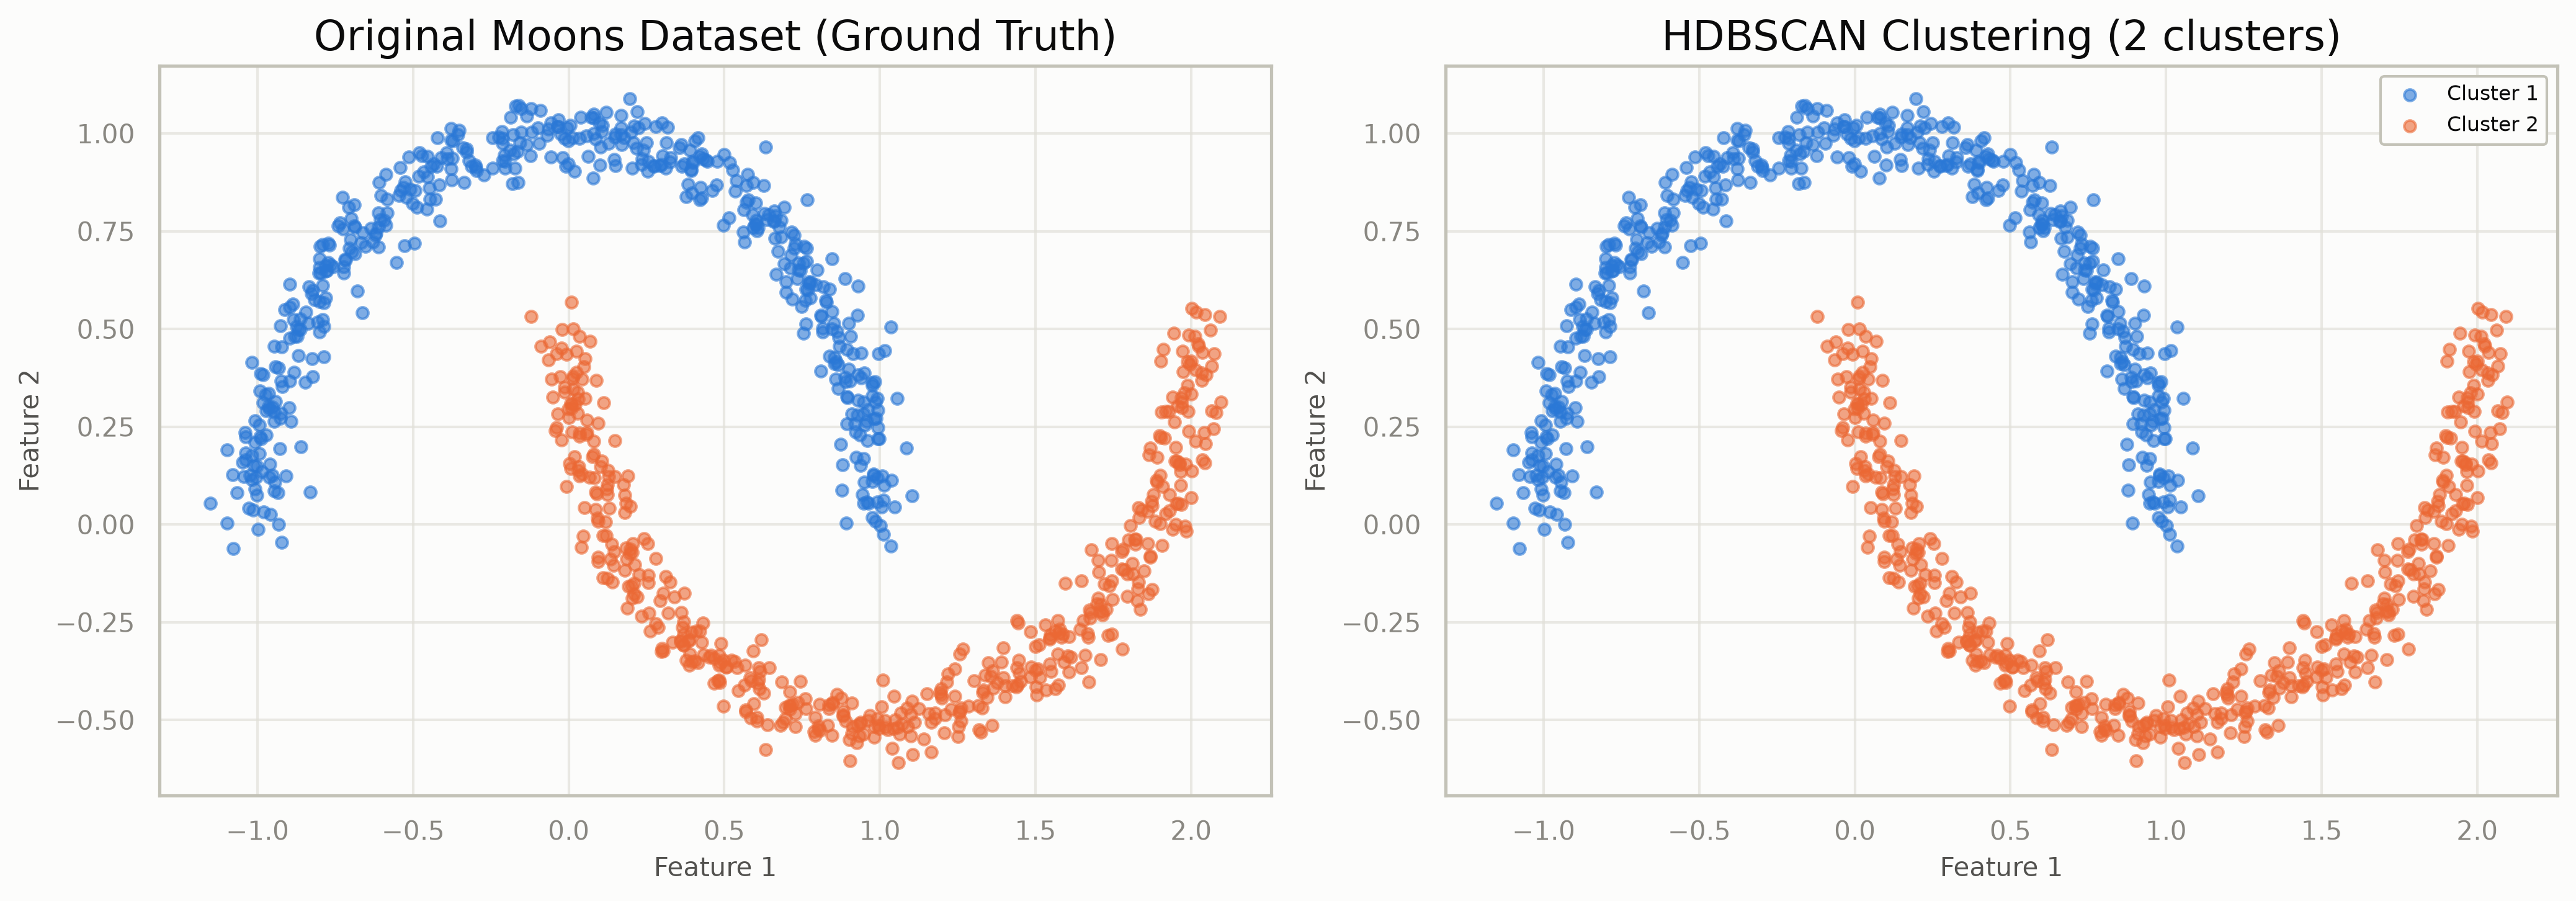

In [2]:
# Generate two interleaving half circles
X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=random_state)
X_moons_tensor = torch.from_numpy(X_moons).float().to(device)

# Fit HDBSCAN
hdbscan_moons = HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric='euclidean',
    device=device
)
labels_moons = hdbscan_moons.fit_predict(X_moons_tensor)

print(f"Number of clusters found: {hdbscan_moons.n_clusters_}")
print(f"Number of noise points: {(labels_moons == -1).sum().item()}")
print(f"Cluster sizes: {[((labels_moons == i).sum().item()) for i in range(hdbscan_moons.n_clusters_)]}")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Original data
plot_gmm(X=X_moons, gmm=None, ax=ax1, true_labels=y_moons, color_by_cluster=True,
         show_ellipses=False, show_means=False, point_size=20, point_alpha=0.6,
         title='Original Moons Dataset (Ground Truth)', legend=False)

# HDBSCAN clustering
labels_np = labels_moons.cpu().numpy()
non_noise = labels_np != -1
plot_gmm(X=X_moons[non_noise], gmm=None, ax=ax2, true_labels=labels_np[non_noise], color_by_cluster=True,
         show_ellipses=False, show_means=False, point_size=20, point_alpha=0.6,
         title=f'HDBSCAN Clustering ({hdbscan_moons.n_clusters_} clusters)', legend=False)
if (~non_noise).any():
    ax2.scatter(X_moons[~non_noise, 0], X_moons[~non_noise, 1], c='red', marker='x', s=50, label='Noise')
ax2.legend()

plt.tight_layout()
plt.show()

## Example 3: Noise Detection Accuracy

`min_samples` and `min_cluster_size` control how aggressively HDBSCAN labels
points as noise. Here we generate data with a known 15% of points injected as
uniform noise, so we can check the detector against ground truth: which points
did it correctly flag as noise, and where did it get the noise/cluster call
wrong (false positives: real points wrongly flagged as noise; false negatives:
actual noise points that slipped through as a cluster)?

(A numerical accuracy check against scikit-learn's HDBSCAN implementation,
confirming the two agree once `min_samples` is defined the same way in both,
lives in `tests/test_hdbscan.py` rather than here.)

Data generated: 690 total points
  - Gaussian points: 600
  - Noise points (ground truth): 90

Detected clusters: 3
Correct noise/cluster calls: 654/690
False positives (wrongly flagged as noise): 1
False negatives (noise missed): 35


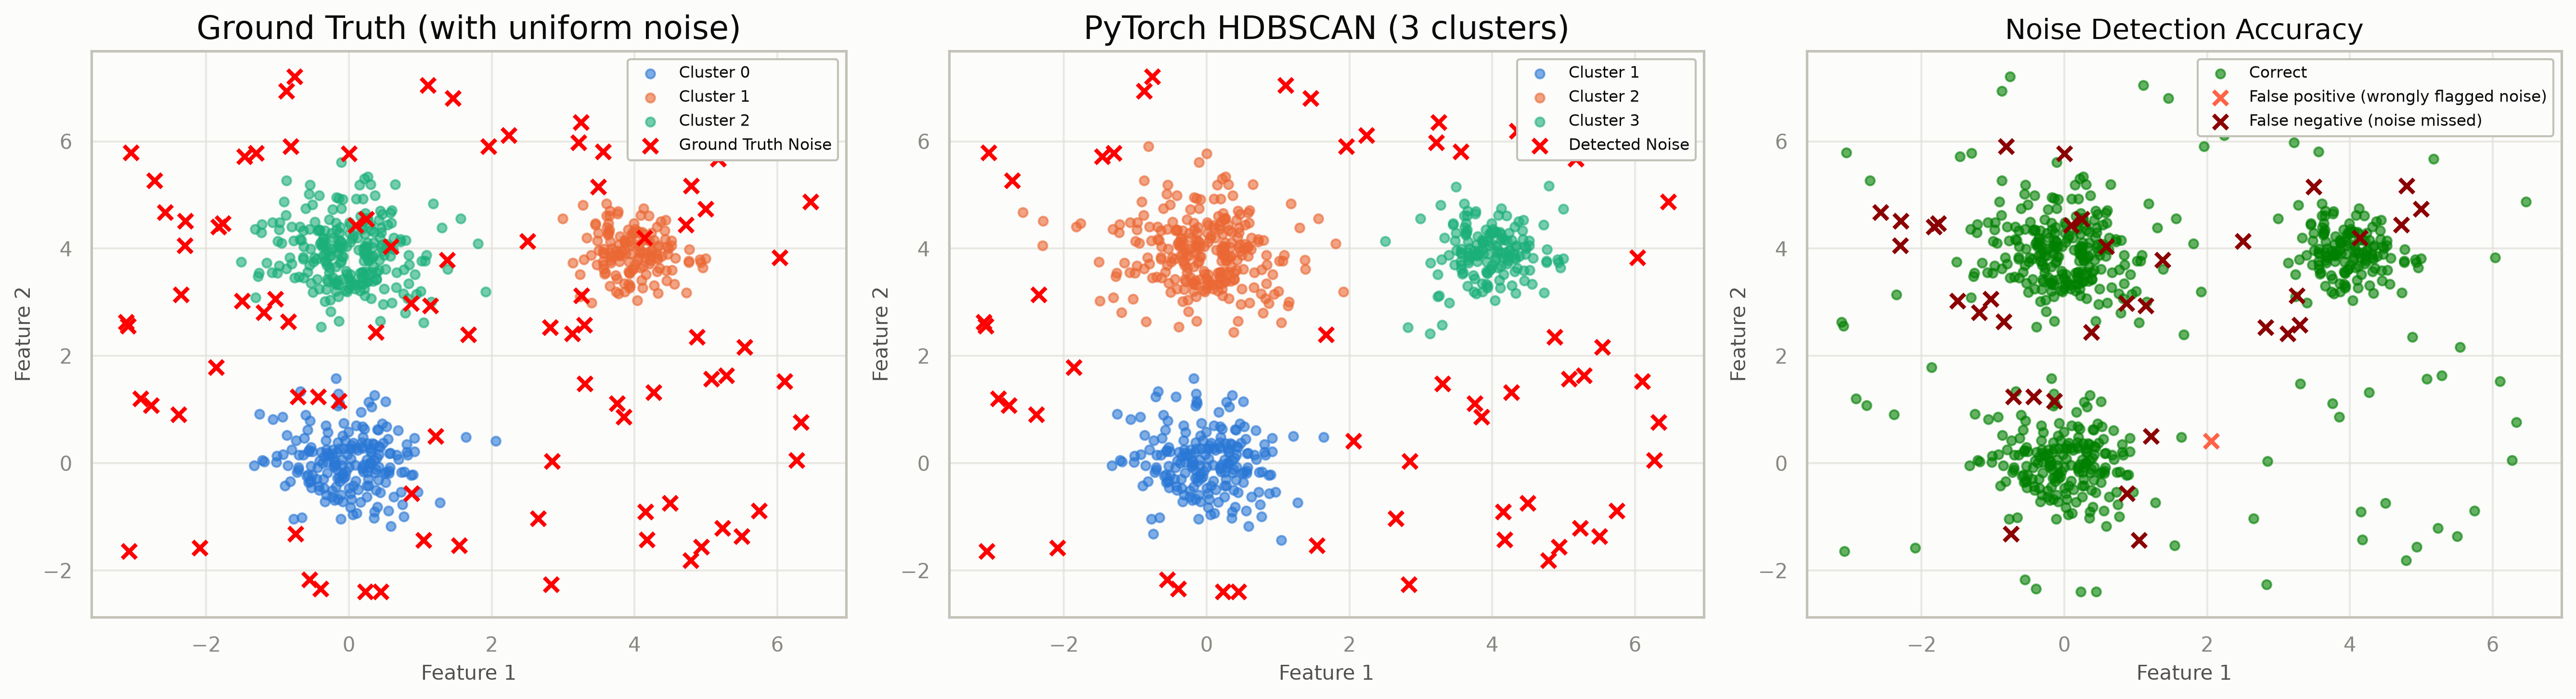

In [3]:
# Generate test data with 15% uniform noise
n_samples_test = [200, 150, 250]
centers_test = [np.array([0, 0]), np.array([4, 4]), np.array([0, 4])]
covs_test = [0.5 * np.eye(2), 0.4 * np.eye(2), 0.6 * np.eye(2)]

X_test, y_test = generate_gmm_data(
    centers_test, covs_test, n_samples_test,
    device=device, random_state=random_state,
    noise_ratio=0.15,  # Add 15% uniform noise
    noise_scale=1.5    # Noise spread 1.5x the data range
)

print(f"Data generated: {X_test.shape[0]} total points")
print(f"  - Gaussian points: {sum(n_samples_test)}")
print(f"  - Noise points (ground truth): {(y_test == -1).sum().item()}\n")

# PyTorch HDBSCAN
hdbscan_torch = HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric='euclidean',
    device=device
)
labels_torch = hdbscan_torch.fit_predict(X_test)

X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()
labels_torch_np = labels_torch.cpu().numpy()

# Classify each point's noise/cluster call against ground truth
true_is_noise = y_test_np == -1
pred_is_noise = labels_torch_np == -1
correct_mask = true_is_noise == pred_is_noise
false_positive_mask = pred_is_noise & ~true_is_noise   # flagged as noise, actually a real point
false_negative_mask = ~pred_is_noise & true_is_noise   # actual noise, missed (kept as cluster)

print(f"Detected clusters: {hdbscan_torch.n_clusters_}")
print(f"Correct noise/cluster calls: {correct_mask.sum()}/{len(y_test_np)}")
print(f"False positives (wrongly flagged as noise): {false_positive_mask.sum()}")
print(f"False negatives (noise missed): {false_negative_mask.sum()}")

# Visualize
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Ground truth
plot_gmm(X=X_test_np[~true_is_noise], gmm=None, ax=ax1, true_labels=y_test_np[~true_is_noise],
         color_by_cluster=True, show_ellipses=False, show_means=False,
         point_size=20, point_alpha=0.6, legend=False,
         title='Ground Truth (with uniform noise)',
         legend_labels=[f'Cluster {i}' for i in range(3)])
if true_is_noise.any():
    ax1.scatter(X_test_np[true_is_noise, 0], X_test_np[true_is_noise, 1],
               c='red', marker='x', s=50, label='Ground Truth Noise', linewidth=2)
ax1.legend()

# PyTorch HDBSCAN
plot_gmm(X=X_test_np[~pred_is_noise], gmm=None, ax=ax2, true_labels=labels_torch_np[~pred_is_noise],
         color_by_cluster=True, show_ellipses=False, show_means=False,
         point_size=20, point_alpha=0.6, legend=False,
         title=f'PyTorch HDBSCAN ({hdbscan_torch.n_clusters_} clusters)')
if pred_is_noise.any():
    ax2.scatter(X_test_np[pred_is_noise, 0], X_test_np[pred_is_noise, 1],
                c='red', marker='x', s=50, label='Detected Noise', linewidth=2)
ax2.legend()

# Noise detection accuracy: correct vs. false positive vs. false negative. This is a
# binary correctness diagnostic rather than a per-cluster labeling, so it doesn't map
# onto plot_gmm's cluster-coloring model -- left as a direct scatter.
ax3.scatter(X_test_np[correct_mask, 0], X_test_np[correct_mask, 1],
            c='green', s=20, alpha=0.6, label='Correct')
if false_positive_mask.any():
    ax3.scatter(X_test_np[false_positive_mask, 0], X_test_np[false_positive_mask, 1],
                c='tomato', marker='x', s=50, label='False positive (wrongly flagged noise)', linewidth=2)
if false_negative_mask.any():
    ax3.scatter(X_test_np[false_negative_mask, 0], X_test_np[false_negative_mask, 1],
                c='darkred', marker='x', s=50, label='False negative (noise missed)', linewidth=2)
ax3.set_title('Noise Detection Accuracy', fontsize=14)
ax3.set_xlabel('Feature 1')
ax3.set_ylabel('Feature 2')
ax3.legend()

plt.tight_layout()
plt.show()

## Example 4: Effect of min_cluster_size Parameter

The `min_cluster_size` parameter controls the minimum size for a cluster. Larger values result in fewer, larger clusters.

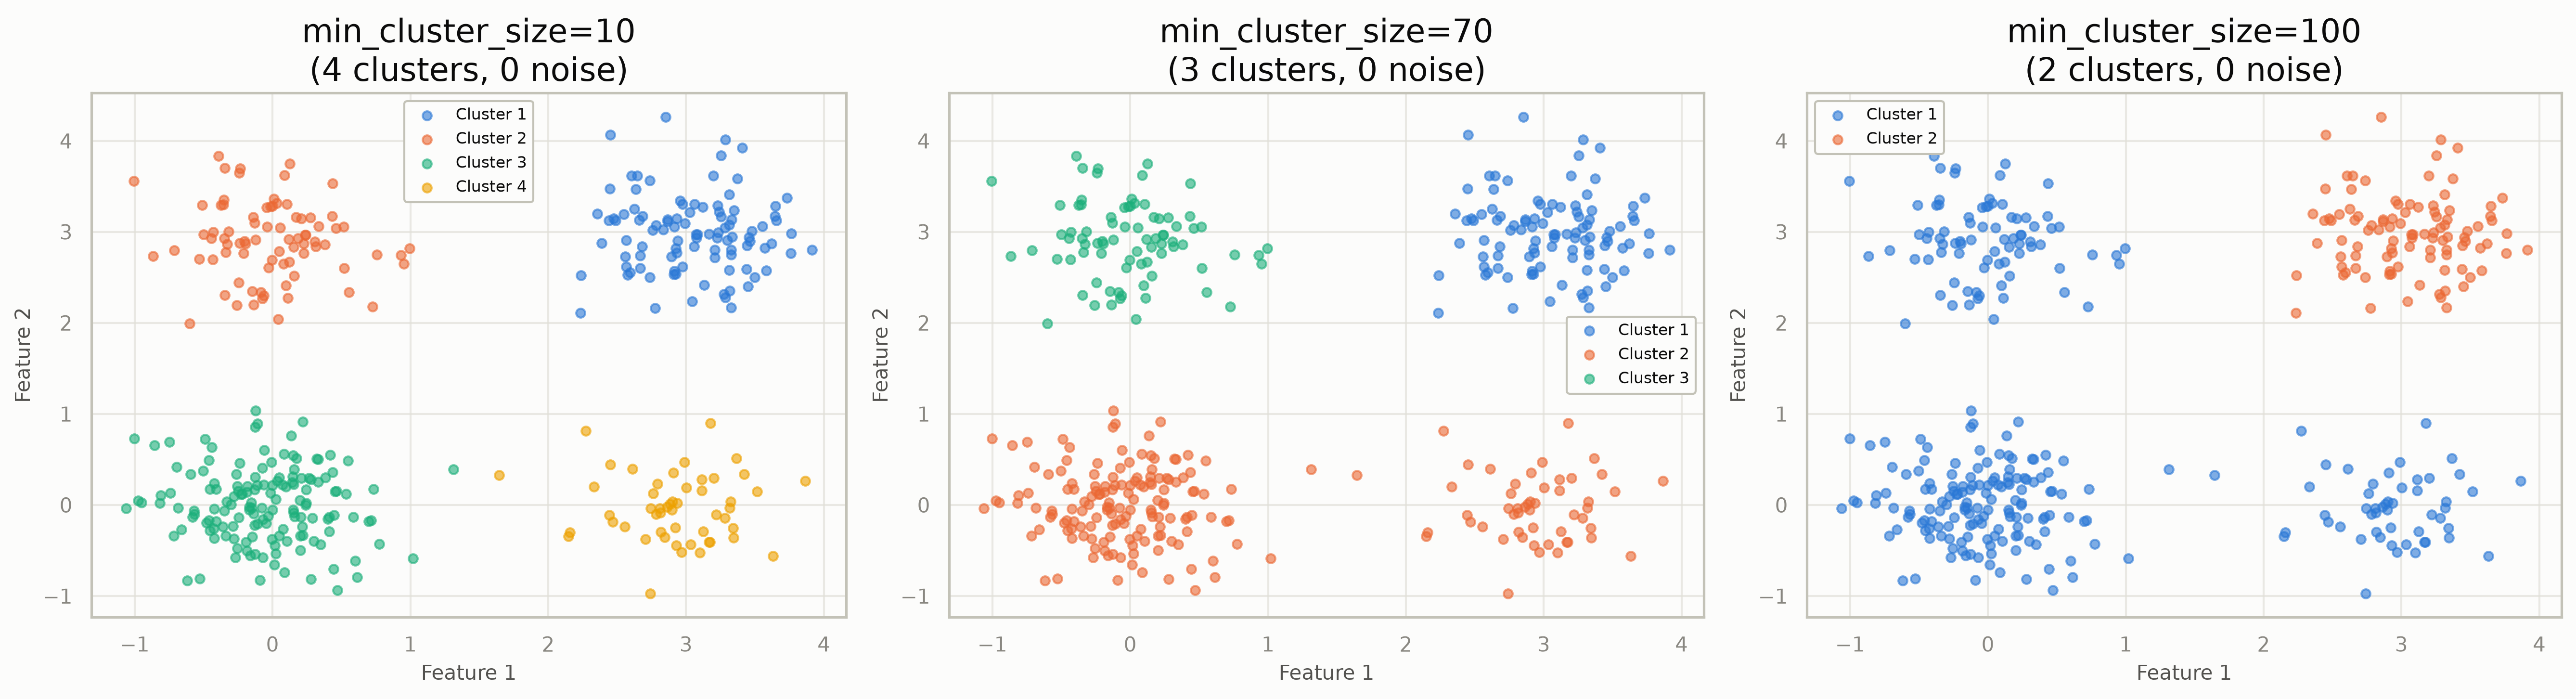

In [4]:
# Generate complex data with noise
n_samples_complex = [150, 100, 80, 50]
centers_complex = [
    np.array([0, 0]), 
    np.array([3, 3]), 
    np.array([0, 3]),
    np.array([3, 0])
]
covs_complex = [0.4 * np.eye(2) for _ in range(4)]

X_complex, y_complex = generate_gmm_data(
    centers_complex, covs_complex, n_samples_complex,
    device=device, random_state=random_state
)

# Try different min_cluster_size values
# The smallest true cluster has 50 points, so anything below that won't
# change what counts as a valid cluster: 10 and 30 will look identical.
# 70 and 100 cross the size of progressively larger true clusters.
min_cluster_sizes = [10, 70, 100]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
X_np = X_complex.cpu().numpy()

for ax, min_size in zip(axes, min_cluster_sizes):
    hdbscan_test = HDBSCAN(
        min_cluster_size=min_size,
        min_samples=5,
        device=device
    )
    labels_test = hdbscan_test.fit_predict(X_complex)
    labels_np = labels_test.cpu().numpy()
    non_noise = labels_np != -1

    plot_gmm(X=X_np[non_noise], gmm=None, ax=ax, true_labels=labels_np[non_noise],
             color_by_cluster=True, show_ellipses=False, show_means=False,
             point_size=20, point_alpha=0.6, legend=False,
             title=f'min_cluster_size={min_size}\n({hdbscan_test.n_clusters_} clusters, '
                   f'{(~non_noise).sum()} noise)')
    if (~non_noise).any():
        ax.scatter(X_np[~non_noise, 0], X_np[~non_noise, 1],
                  c='red', marker='x', s=50, label='Noise')
    ax.legend()

plt.tight_layout()
plt.show()

## Example 5: Different Distance Metrics

HDBSCAN supports multiple distance metrics, and the "right" one depends on what
actually distinguishes your clusters. Below, three synthetic datasets are each
built so that a *different* metric is the one that recovers the true clusters
correctly, then all three metrics are run on all three datasets (same
`min_cluster_size`/`min_samples` throughout, so the comparison isolates the
effect of the metric alone):

- **Collinear blobs** — clusters differ only in *distance from the origin*, not
  direction. Cosine distance ignores magnitude entirely, so it can't tell these
  apart (everything looks like noise); Euclidean/Manhattan separate them easily.
- **Rectilinear blob chains** — two "L-shaped" chains of uniform *square*
  blobs (each chain running along a single axis, then turning at a corner)
  plus a third, standalone square blob off on its own. Manhattan's unit ball
  is itself a diamond aligned with the axes, so it bridges the small gaps
  between axis-aligned square blobs cleanly and recovers all 3 true clusters
  perfectly. Euclidean's circular neighborhoods don't extend as efficiently
  across a flat, straight gap, so each chain fragments into one cluster per
  blob (the standalone blob, needing no bridging, is the one thing it still
  gets right).
- **Angular wedges** — clusters differ only in *direction from the origin*, with
  overlapping radius ranges. Cosine distance is direction-only, so it separates
  these cleanly; Euclidean/Manhattan get confused because points from different
  wedges can be closer in raw distance than points within the same wedge.


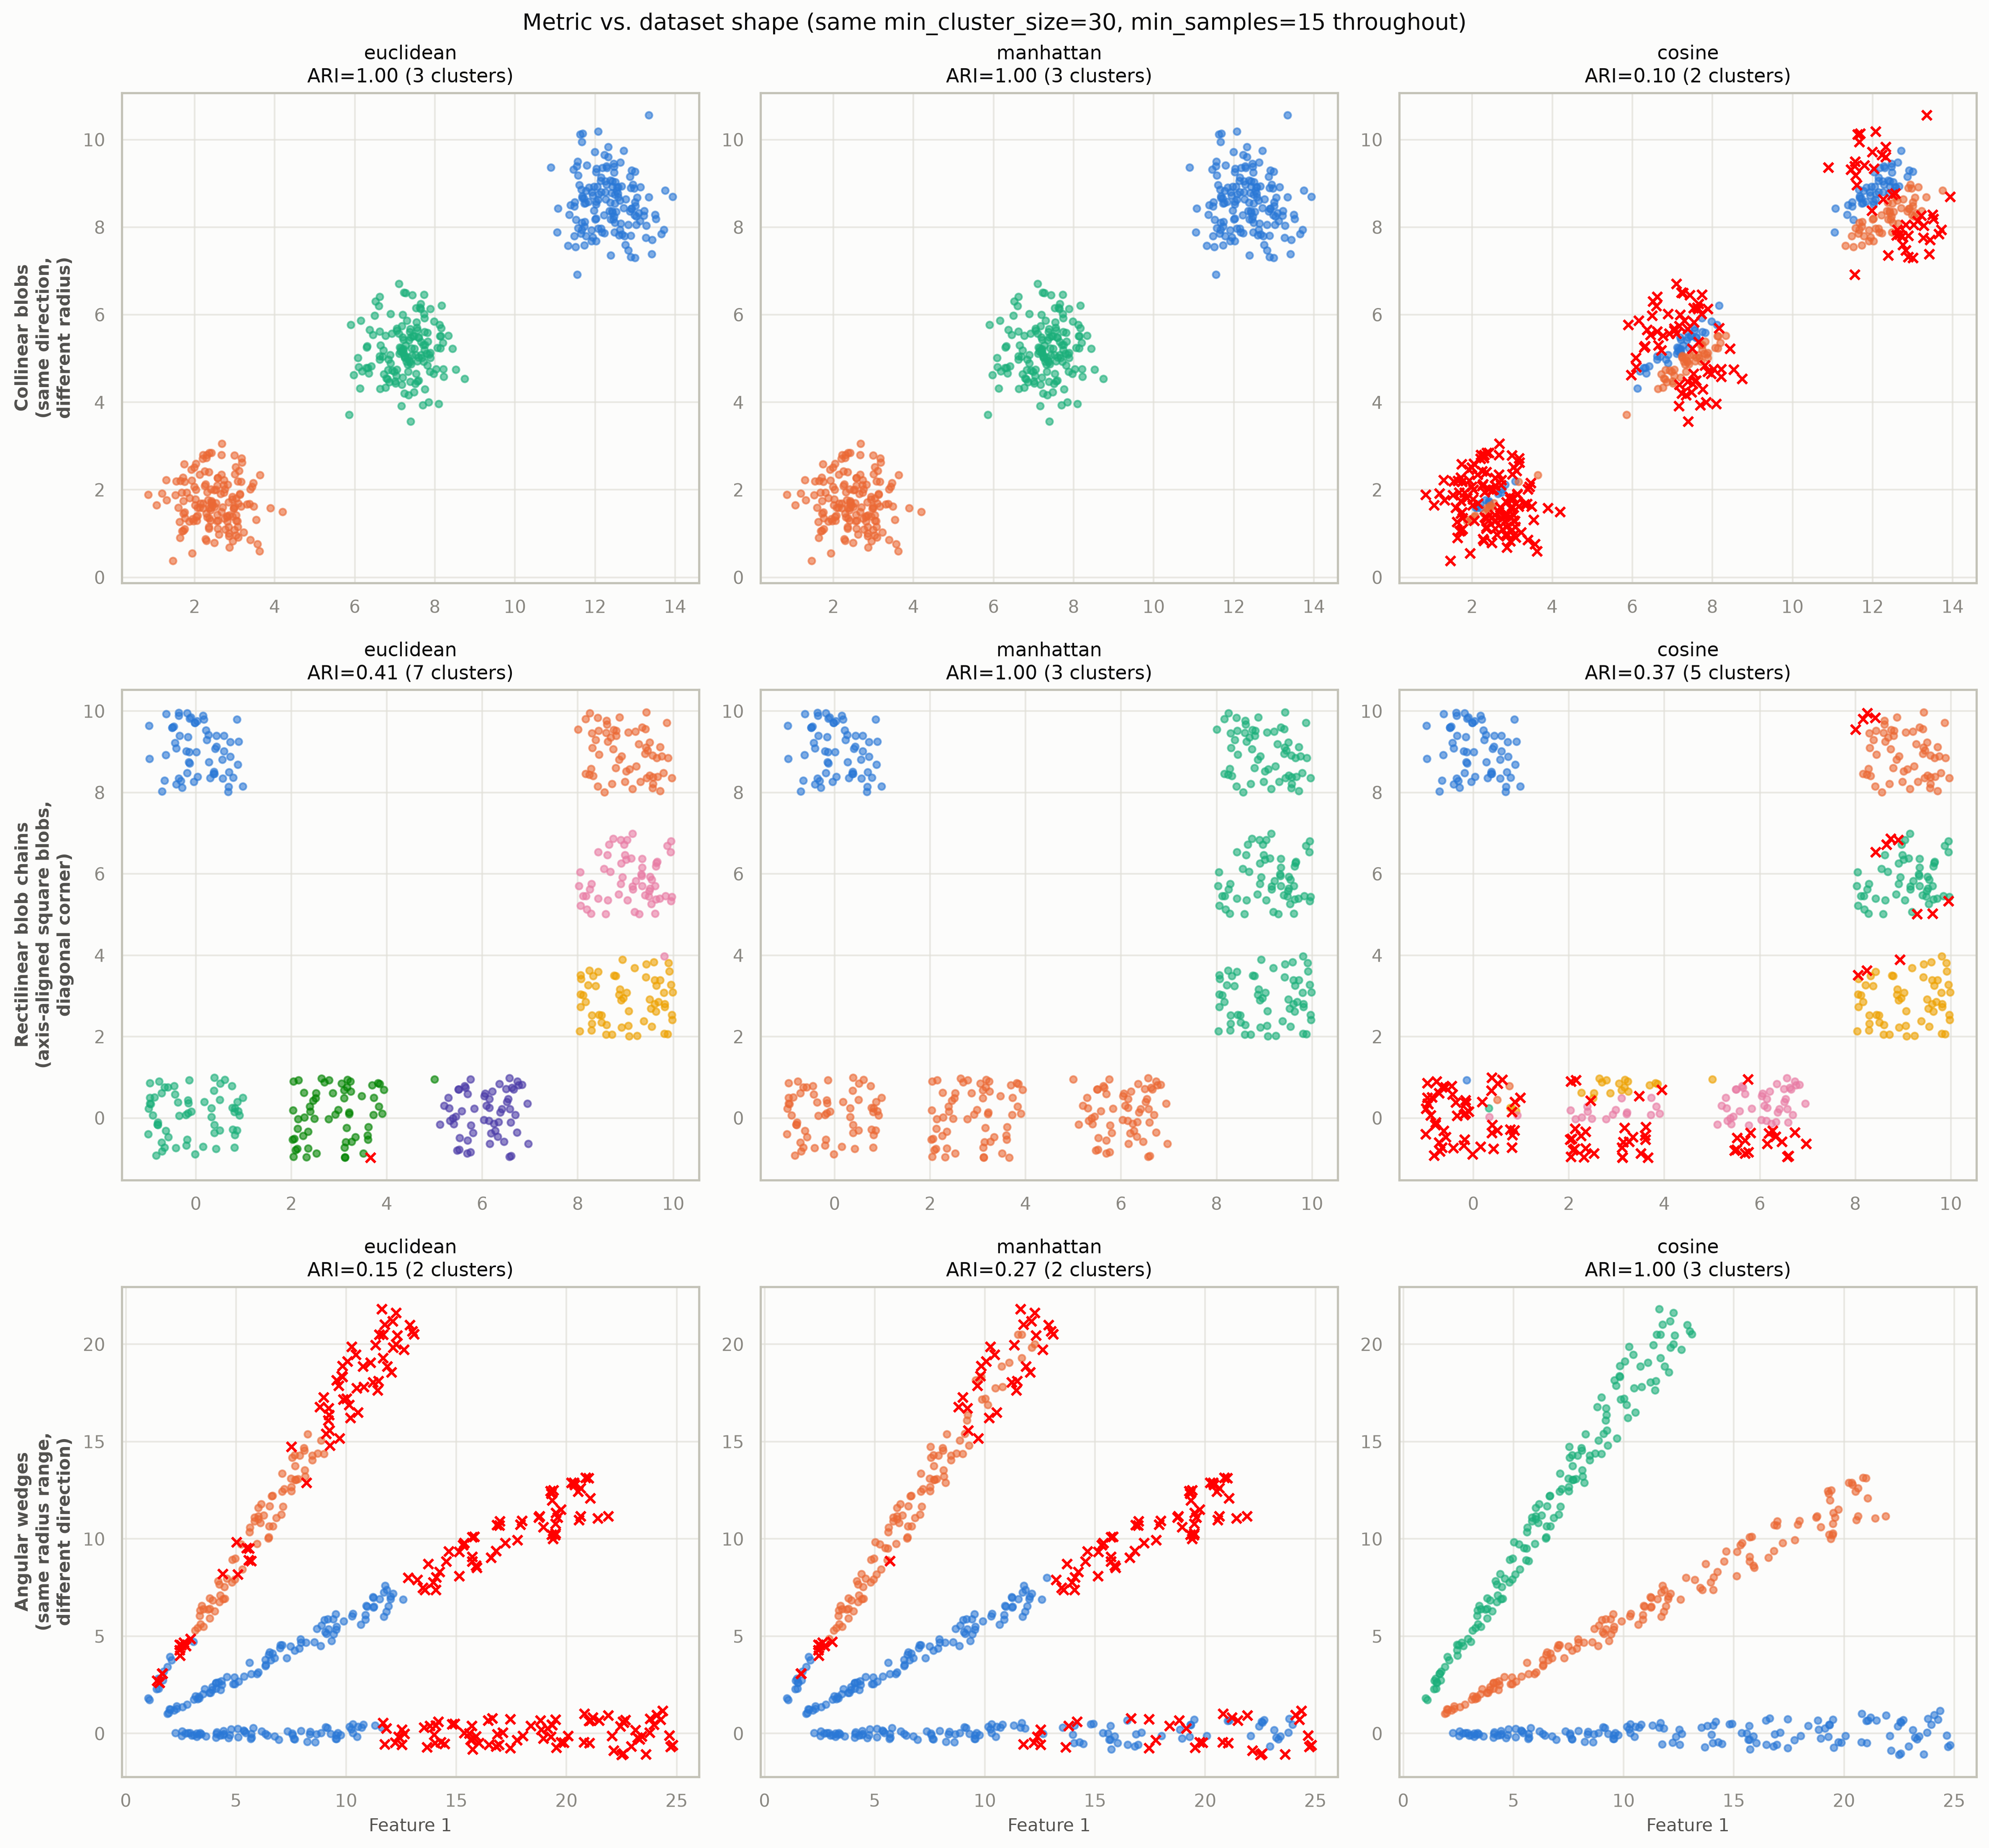

In [5]:
from sklearn.metrics import adjusted_rand_score


def make_wedges(angles, r_range, jitter_deg, n_per, seed):
    """Clusters separated by direction from the origin, overlapping in radius."""
    rs = np.random.RandomState(seed)
    def wedge(angle_deg):
        angle = np.deg2rad(angle_deg + rs.uniform(-jitter_deg, jitter_deg, n_per))
        r = rs.uniform(*r_range, n_per)
        return np.stack([r * np.cos(angle), r * np.sin(angle)], axis=1)
    X = np.vstack([wedge(a) for a in angles])
    y = np.repeat(range(len(angles)), n_per)
    return X, y


def make_collinear_blobs(r_centers, r_std, perp_std, angle_deg, n_per, seed):
    """Clusters separated by distance from the origin, along the same direction."""
    rs = np.random.RandomState(seed)
    angle = np.deg2rad(angle_deg)
    direction = np.array([np.cos(angle), np.sin(angle)])
    perp = np.array([-np.sin(angle), np.cos(angle)])
    def blob(r_center):
        r = rs.normal(r_center, r_std, n_per)
        p = rs.normal(0, perp_std, n_per)
        return r[:, None] * direction + p[:, None] * perp
    X = np.vstack([blob(rc) for rc in r_centers])
    y = np.repeat(range(len(r_centers)), n_per)
    return X, y


X_collinear, y_collinear = make_collinear_blobs(
    r_centers=[3, 9, 15], r_std=0.6, perp_std=0.6, angle_deg=35, n_per=150, seed=11
)
def make_rectilinear_chains(step, side, n_per_blob, n_arm, seed, extra_center):
    """Two L-shaped chains of uniform square blobs (one runs horizontally,
    the other picks up vertically at a diagonal corner from the first) plus
    a third, standalone square blob that belongs to neither chain."""
    rs = np.random.RandomState(seed)

    def square_blob(cx, cy):
        return rs.uniform(-side / 2, side / 2, size=(n_per_blob, 2)) + np.array([cx, cy])

    blobs = [square_blob(i * step, 0) for i in range(n_arm)]
    corner_x, corner_y = n_arm * step, step
    blobs += [square_blob(corner_x, corner_y + i * step) for i in range(n_arm)]
    blobs.append(square_blob(*extra_center))
    X = np.vstack(blobs)
    y_labels = np.array([0] * (n_arm * n_per_blob) + [1] * (n_arm * n_per_blob) + [2] * n_per_blob)
    return X, y_labels


X_chains, y_chains = make_rectilinear_chains(
    step=3, side=2, n_per_blob=60, n_arm=3, seed=1, extra_center=(0, 9)
)
X_wedges, y_wedges = make_wedges(
    angles=[0, 30, 60], r_range=(2, 25), jitter_deg=3, n_per=150, seed=7
)

datasets = [
    ('Collinear blobs\n(same direction,\ndifferent radius)', X_collinear, y_collinear),
    ('Rectilinear blob chains\n(axis-aligned square blobs,\ndiagonal corner)', X_chains, y_chains),
    ('Angular wedges\n(same radius range,\ndifferent direction)', X_wedges, y_wedges),
]
metrics = ['euclidean', 'manhattan', 'cosine']

fig, axes = plt.subplots(3, 3, figsize=(16, 15))

for row, (name, X_ds, y_ds) in enumerate(datasets):
    X_tensor = torch.from_numpy(X_ds).float().to(device)
    for col, metric in enumerate(metrics):
        ax = axes[row, col]
        hdbscan_metric = HDBSCAN(
            min_cluster_size=30,
            min_samples=15,
            metric=metric,
            device=device
        )
        labels = hdbscan_metric.fit_predict(X_tensor).cpu().numpy()
        ari = adjusted_rand_score(y_ds, labels)
        non_noise = labels != -1

        plot_gmm(X=X_ds[non_noise], gmm=None, ax=ax, true_labels=labels[non_noise],
                 color_by_cluster=True, show_ellipses=False, show_means=False,
                 point_size=15, point_alpha=0.6, legend=False,
                 title=f'{metric}\nARI={ari:.2f} ({hdbscan_metric.n_clusters_} clusters)',
                 xlabel=None, ylabel=None)
        if non_noise.sum() < len(labels):
            ax.scatter(X_ds[~non_noise, 0], X_ds[~non_noise, 1],
                       c='red', marker='x', s=30, alpha=1.0, linewidth=1.5)

        ax.set_title(ax.get_title(), fontsize=11)
        if col == 0:
            ax.set_ylabel(name, fontsize=10, fontweight='bold')
        if row == len(datasets) - 1:
            ax.set_xlabel('Feature 1')

fig.suptitle(
    'Metric vs. dataset shape (same min_cluster_size=30, min_samples=15 throughout)',
    fontsize=13
)
plt.tight_layout()
plt.show()

## Example 6: Using HDBSCAN to Clean Data Before Fitting a GMM

HDBSCAN's noise label is useful as a preprocessing step for models like GMM
that assume every point belongs to some component -- outliers can otherwise
drag component means and inflate covariances. Below: two known Gaussians
(means/covariances shown as reference ellipses) with uniform noise added on
top, a GMM fit directly on that noisy data, HDBSCAN's noise flagging on the
same data, and a GMM re-fit only on the points HDBSCAN kept.

Points: 494 total, 114 injected noise
HDBSCAN flagged 97 points as noise, kept 397

Mean error vs. truth        - raw GMM: 0.463   cleaned GMM: 0.155
Covariance error vs. truth  - raw GMM: 9.642   cleaned GMM: 0.442


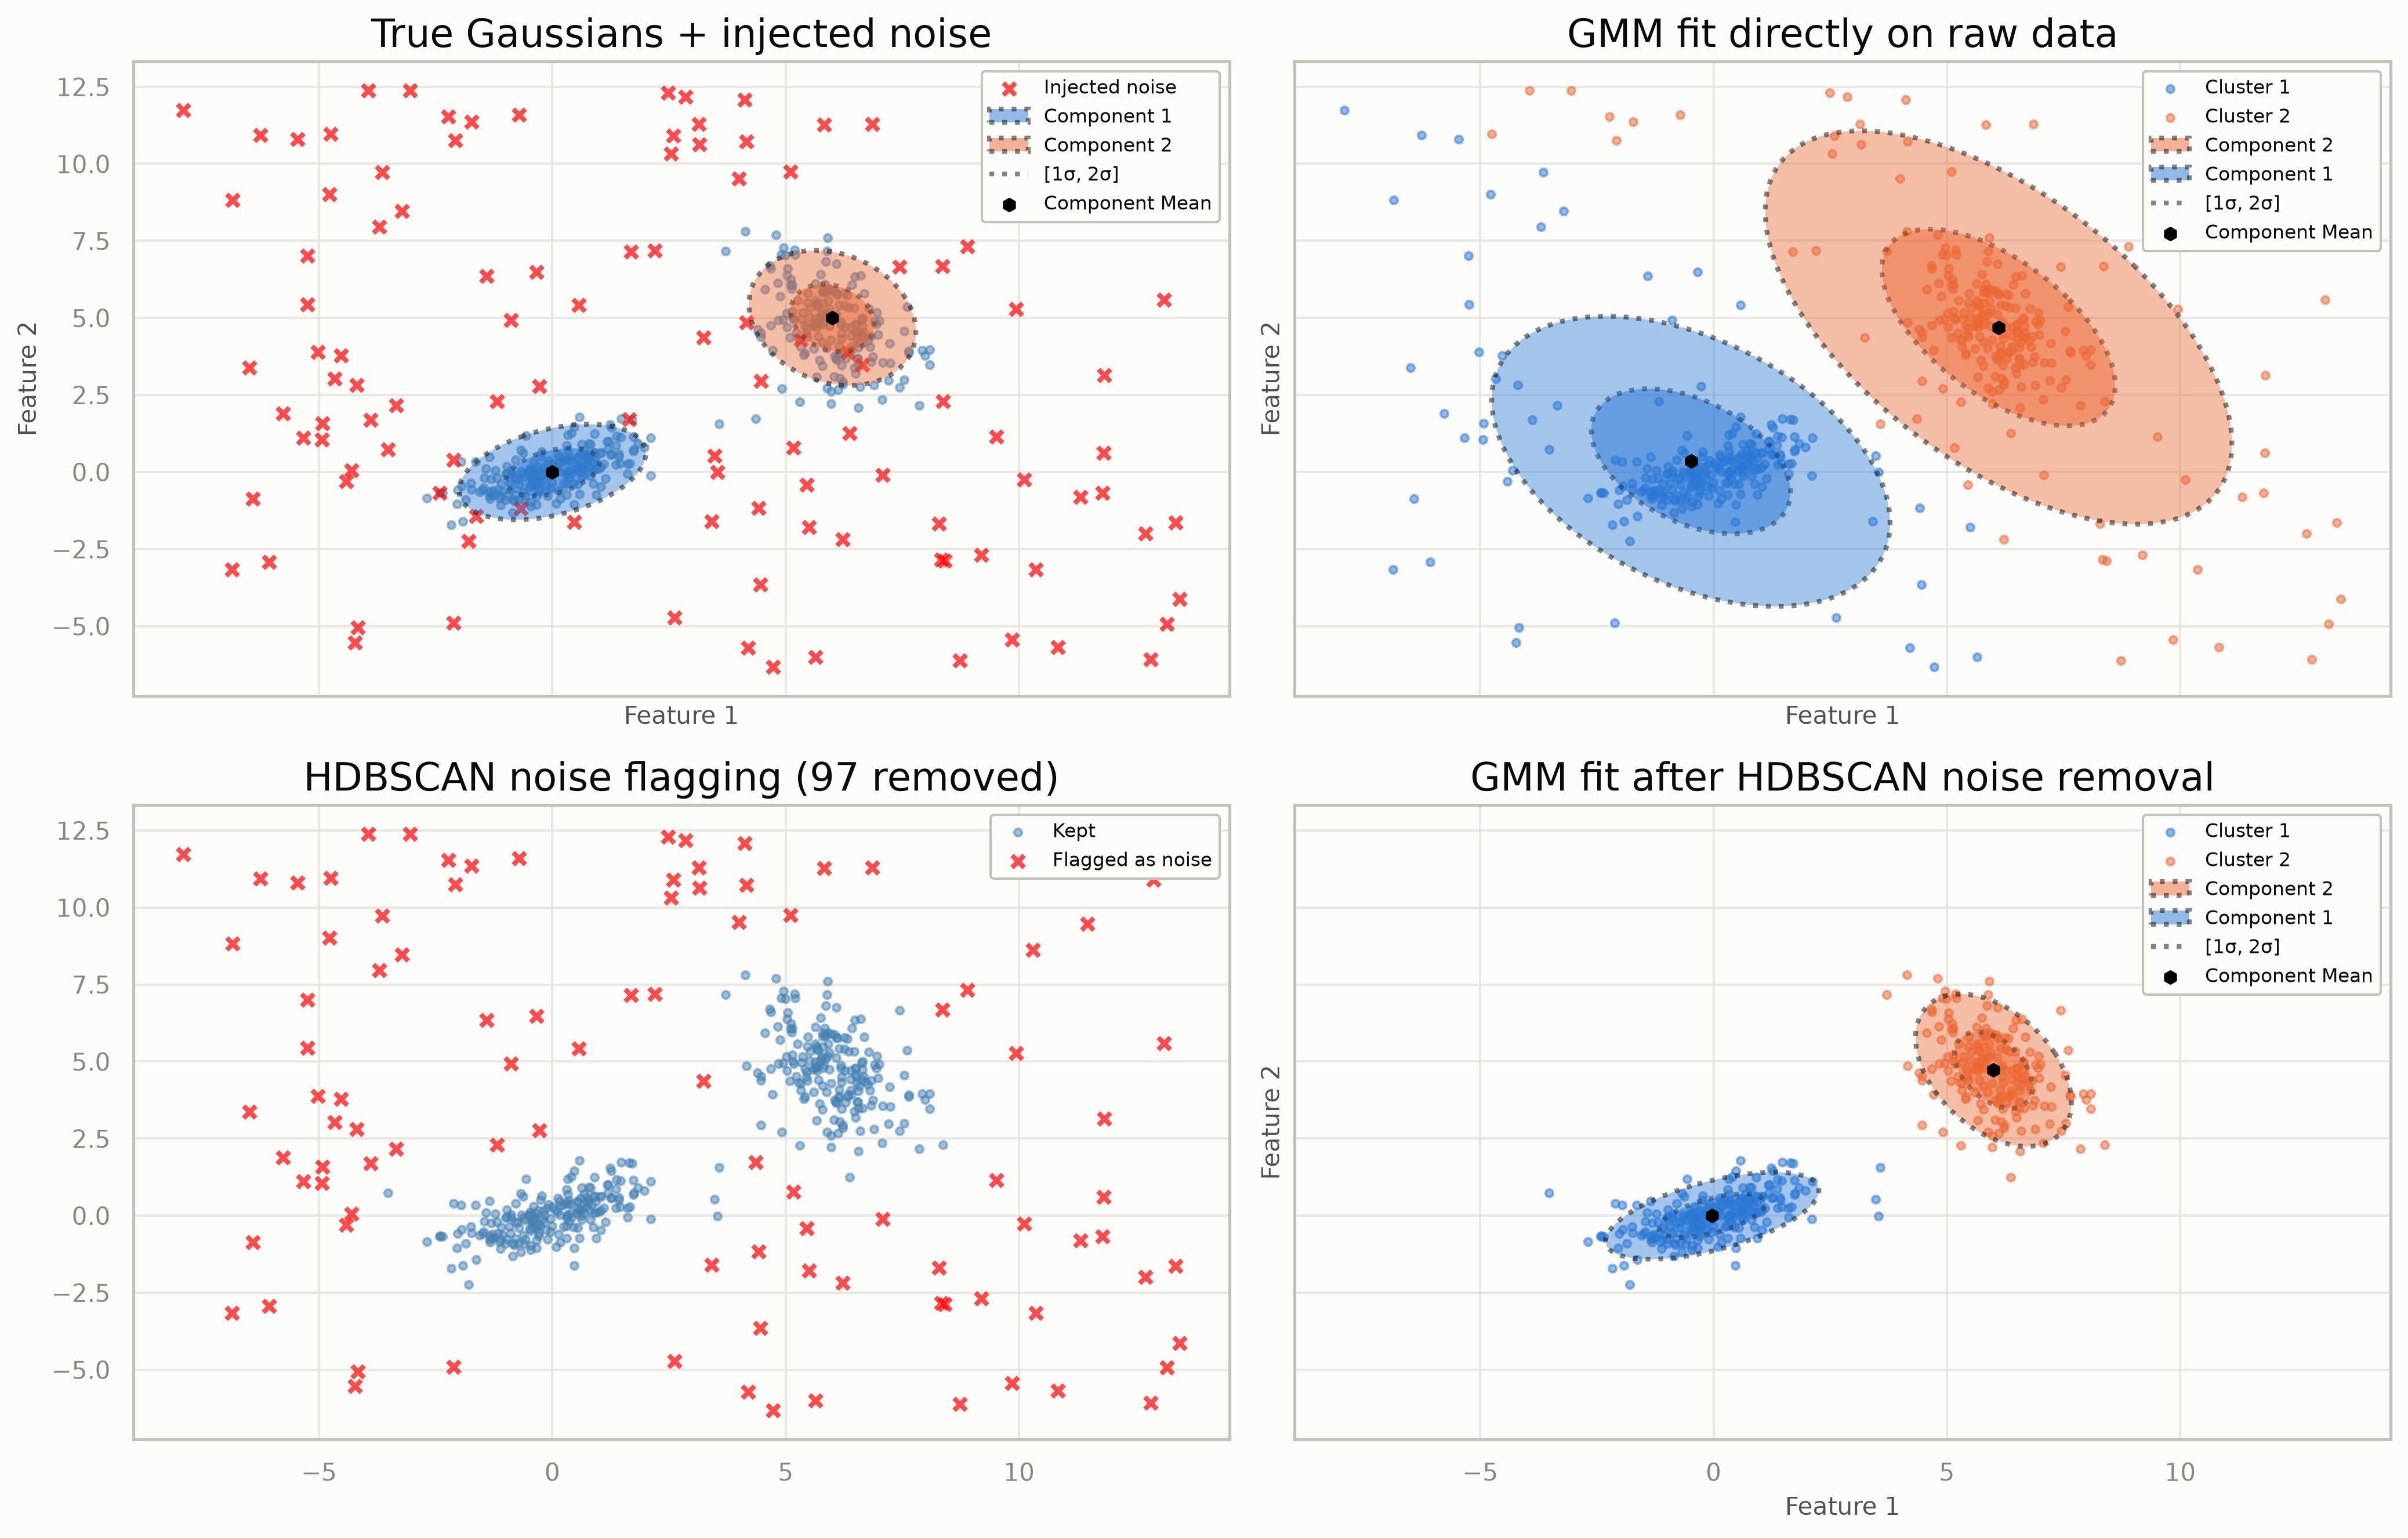

In [6]:
centers_demo = [np.array([0, 0]), np.array([6, 5])]
covs_demo = [
    np.array([[1.0, 0.3], [0.3, 0.6]]),
    np.array([[0.8, -0.2], [-0.2, 1.2]]),
]
n_samples_demo = [200, 180]

X_demo, y_demo = generate_gmm_data(
    centers_demo, covs_demo, n_samples_demo,
    device=device, random_state=random_state,
    noise_ratio=0.3,   # 30% of points are uniform noise
    noise_scale=2.0
)
X_demo_np = X_demo.cpu().numpy()
y_demo_np = y_demo.cpu().numpy()

# Proxy GMM holding the *true* generating parameters, so plot_gmm can draw
# the true mean/std ellipses even though no GaussianMixture was fit to get them.
true_proxy = gmm_proxy(
    means=np.stack(centers_demo), covariances=np.stack(covs_demo),
    covariance_type='full', predicted_labels=np.zeros(len(X_demo), dtype=int),
)

# Fit a GMM directly on the raw, noisy data
gmm_raw = GaussianMixture(n_components=2, random_state=random_state)
gmm_raw.fit(X_demo)

# Use HDBSCAN to flag noise, then keep only the points it considers "real"
hdbscan_demo = HDBSCAN(min_cluster_size=30, min_samples=15, device=device)
labels_demo = hdbscan_demo.fit_predict(X_demo)
labels_demo_np = labels_demo.cpu().numpy()
keep_mask = labels_demo_np != -1
X_clean = X_demo[torch.from_numpy(keep_mask)]

# Fit a GMM again, this time only on the HDBSCAN-cleaned points
gmm_clean = GaussianMixture(n_components=2, random_state=random_state)
gmm_clean.fit(X_clean)


def mean_error(gmm, true_centers):
    means = gmm.means_.cpu().numpy()
    return np.mean([np.linalg.norm(means - c, axis=1).min() for c in true_centers])


def cov_error(gmm, true_centers, true_covs):
    means = gmm.means_.cpu().numpy()
    covs = gmm.covariances_.cpu().numpy()
    errs = []
    for c, cov in zip(true_centers, true_covs):
        idx = np.argmin(np.linalg.norm(means - c, axis=1))
        errs.append(np.linalg.norm(covs[idx] - cov))
    return np.mean(errs)


print(f"Points: {X_demo.shape[0]} total, {(y_demo_np == -1).sum()} injected noise")
print(f"HDBSCAN flagged {(~keep_mask).sum()} points as noise, kept {keep_mask.sum()}\n")
print(f"Mean error vs. truth        - raw GMM: {mean_error(gmm_raw, centers_demo):.3f}   "
      f"cleaned GMM: {mean_error(gmm_clean, centers_demo):.3f}")
print(f"Covariance error vs. truth  - raw GMM: {cov_error(gmm_raw, centers_demo, covs_demo):.3f}   "
      f"cleaned GMM: {cov_error(gmm_clean, centers_demo, covs_demo):.3f}")

fig, axes = plt.subplots(2, 2, figsize=dynamic_figsize(2, 2), sharex=True, sharey=True)

# Top-left: raw noisy data with the *true* generating Gaussians as reference
axes[0, 0].scatter(X_demo_np[y_demo_np != -1, 0], X_demo_np[y_demo_np != -1, 1],
                    c='steelblue', s=10, alpha=0.5)
axes[0, 0].scatter(X_demo_np[y_demo_np == -1, 0], X_demo_np[y_demo_np == -1, 1],
                    c='red', marker='x', s=25, alpha=0.7, label='Injected noise')
plot_gmm(X=X_demo, gmm=true_proxy, ax=axes[0, 0], title='True Gaussians + injected noise',
         show_points=False, show_ellipses=True, ellipse_std_devs=[1, 2],
         show_means=True, legend=True)
axes[0, 0].legend(fontsize=8, loc='upper right')

# Top-right: GMM fit directly on the raw (noisy) data. true_labels +
# match_labels_to_true so the same physical Gaussian gets the same color
# here as in every other panel, regardless of which component index the
# fit happened to assign it internally.
plot_gmm(X=X_demo, gmm=gmm_raw, ax=axes[0, 1], title='GMM fit directly on raw data',
         color_by_cluster=True, true_labels=y_demo_np, match_labels_to_true=True,
         show_ellipses=True, ellipse_std_devs=[1, 2],
         show_means=True, point_size=10, legend=True)
axes[0, 1].legend(fontsize=8, loc='upper right')

# Bottom-left: which points HDBSCAN flagged as noise (and would remove)
axes[1, 0].scatter(X_demo_np[keep_mask, 0], X_demo_np[keep_mask, 1],
                    c='steelblue', s=10, alpha=0.5, label='Kept')
axes[1, 0].scatter(X_demo_np[~keep_mask, 0], X_demo_np[~keep_mask, 1],
                    c='red', marker='x', s=25, alpha=0.7, label='Flagged as noise')
axes[1, 0].set_title(f'HDBSCAN noise flagging ({(~keep_mask).sum()} removed)')
axes[1, 0].legend(fontsize=8, loc='upper right')

# Bottom-right: GMM fit again, this time only on the HDBSCAN-cleaned points.
# Same true_labels/match_labels_to_true trick, masked down to the kept points.
plot_gmm(X=X_clean, gmm=gmm_clean, ax=axes[1, 1], title='GMM fit after HDBSCAN noise removal',
         color_by_cluster=True, true_labels=y_demo_np[keep_mask], match_labels_to_true=True,
         show_ellipses=True, ellipse_std_devs=[1, 2],
         show_means=True, point_size=10, legend=True)
axes[1, 1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()